In [1]:
#jax-forge imports
from jax_forge.lib.sim_handler import SimulationHandler
from jax_forge.lib.mesh_container import MeshContainer
from jax_forge.data_storage.database_handler import DBMS
from jax_forge.data_storage.series_viewer import visualize_series_parallel
from jax_forge.utils.utils import get_jaxforge_root,get_project_mesh_dict
from jax_forge.utils.utils import eulerxyz_to_quat
import pyvista as pv
import gmsh
import numpy as np
import uuid
import glob
import yaml
import math
import json
from tqdm import tqdm
from pathlib import Path


       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



In [2]:
start_mesh_path = Path("/local/scratch/groves/jax-forgeRL/jax-forge/jax_forge/meshes/obj/rescaled_rect_stock.obj")

In [3]:
from dataclasses import dataclass, field
@dataclass
class PressInfo:
    name: str = ""
    width: int = 1
    height: int = 3
    direction: list[float] = field(default_factory=lambda: [0, 1, 0])

    def get_dict(self) -> "dict[str,object]":
        return {"Name": self.name, "Width": self.width, "Height": self.height}

def mesh_dict_to_pv(mesh_dict):
    num_steps = len(mesh_dict["Steps"])
    print(num_steps)
    vertices = np.array(mesh_dict["Vertices"]).reshape(-1,3)
    triangles = np.array(mesh_dict["Triangles"]).reshape(-1,3)

    #   point_arrays = onp.array(combined_meshes["Vertices"]).reshape(steps, -1).tolist()
    n_faces = len(triangles)
    face_array = np.hstack([
        np.full((n_faces, 1), 3),
        triangles
    ]).astype(np.int64)
    
    vertices = vertices.reshape(num_steps,-1)[-1]
    triangles = triangles.reshape(num_steps,-1)[-1]

    return(pv.PolyData(vertices, face_array))



In [4]:
#conduct hit in jax-forge
d = 0.35
t = [0, 0, 0]
r = eulerxyz_to_quat((0,0,0))
press_id = 2
press_info = PressInfo()

proc_mesh = MeshContainer.from_obj(start_mesh_path)

sim_handler = SimulationHandler(press_info=press_info, mesh_data=proc_mesh)

start_mesh = sim_handler.get_unity_result()
proc_mesh.get_surface()
proc_mesh_dict = proc_mesh.serialize_obj()
proc_mesh_dict.update({"Steps" : [1]})
pv_start = mesh_dict_to_pv(proc_mesh_dict)

out_mesh = sim_handler.execute_simulation_adaptive_step(force=d, translation_vector=t, quaternion=r)
result_mesh = sim_handler.get_unity_result()
pv_out = mesh_dict_to_pv(result_mesh)



Model size: 8.665240748313447
Attempting mesh generation with HXT...
HXT meshing successful


[05-22 16:30:08][DEBUG] jax_forge.jax_fem: Computing shape function values, gradients, etc.
[05-22 16:30:08][DEBUG] jax_forge.jax_fem: ele_type = TET4, quad_points.shape = (num_quads, dim) = (1, 3)
[05-22 16:30:08][DEBUG] jax_forge.jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 1, 3)
[05-22 16:30:08][DEBUG] jax_forge.jax_fem: Done pre-computations, took 0.0319366455078125 [s]
[05-22 16:30:08][INFO] jax_forge.jax_fem: Solving a problem with 32564 cells, 7209x3 = 21627 dofs.



Mesh Quality Metrics:
Number of elements: 32564
Average aspect ratio: 1.327
Maximum aspect ratio: 2.292
Volume ratio (max/min): 26.234
1
STEP 1
0.03
DirichletBCInfo: 0.1395730972290039
PETSc linear solver failed to converge, err = 0.202171663921602
STEP 1
0.015
DirichletBCInfo: 0.12863874435424805
Simulation: 3.737010955810547
STEP 2
0.0225
DirichletBCInfo: 0.01983332633972168
Simulation: 1.814859390258789
STEP 3
0.03375
DirichletBCInfo: 0.022025346755981445
Simulation: 1.8340682983398438
STEP 4
0.050625
DirichletBCInfo: 0.020507335662841797
Simulation: 2.4982285499572754
STEP 5
0.0759375
DirichletBCInfo: 0.020513296127319336
PETSc linear solver failed to converge, err = 0.10641453450325027
STEP 5
0.03796875
DirichletBCInfo: 0.021533489227294922
Simulation: 2.3355979919433594
STEP 6
0.05695312500000001
DirichletBCInfo: 0.020732879638671875
Simulation: 2.392531394958496
STEP 7
0.08542968750000002
DirichletBCInfo: 0.022238492965698242
PETSc linear solver failed to converge, err = 0.1190

In [5]:

pv_out = mesh_dict_to_pv(result_mesh)

# len(result_mesh["Vertices"]) / len(result_mesh["Steps"])

9


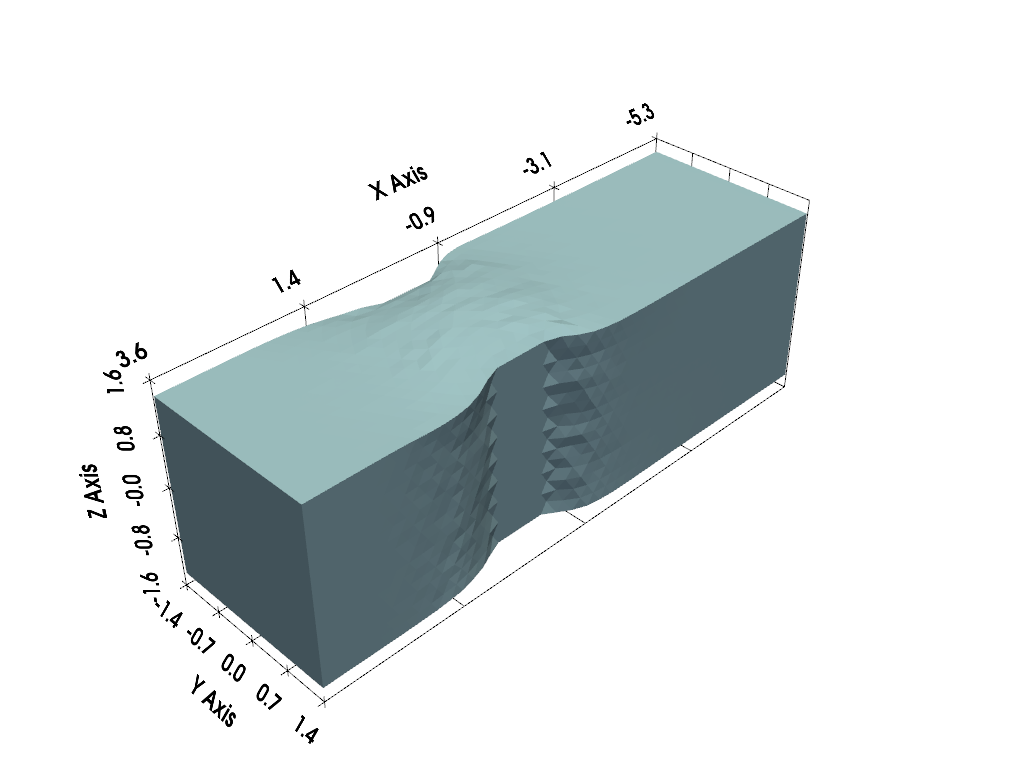

In [6]:
pv.start_xvfb()
pv.set_jupyter_backend('static')
pl = pv.Plotter()
# pl.add_mesh(pv_start)
pl.add_mesh(pv_out)
pl.show_grid()
pl.show()

In [7]:
#forgenet imports
import torch
from forge_net.utils.common import *
from forge_net.utils.math import *
from forge_net.utils.plotting import * 
from forge_net.data.process_data import make_dataloaders, make_dataset
from forge_net.invert_deltas import invert_deltas_to_mesh, save_comparison_turntable
from tqdm import tqdm 

#Evalauate an existing trained model
from forge_net.model.trainer import ForgeNetTrainer
import yaml

base_path = get_project_root()
run_name = "mse_1024_unmasked_seeded_tri_ids"
config_path = base_path / "runs" / run_name / "config_out.yml"
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)
train_loader, test_loader = make_dataloaders(config)
trainer = ForgeNetTrainer(config, train_loader, log_to_tb=False)
output_folder = Path(config["run"]["run_folder"])
eval_path = output_folder / "eval"
eval_path.mkdir(exist_ok=True)

trainer.load(model_path = output_folder / "best_model.pth")
trainer.net.eval()

data_path = config["datasets"]["data_out"]
assert os.path.exists(data_path), "Dataset found"
data  = np.load(data_path)
states = data['coords_t']
states_tp1 = data['coords_tp1']
action_features = config["network"]["action_features"]

actions = actions_from_feature_map(action_features, data)

output_folder = Path(config["run"]["run_folder"])
eval_path = output_folder / "eval"
eval_path.mkdir(exist_ok=True)

trainer.load(model_path = output_folder / "best_model.pth")

def forward(x,a):
    with torch.no_grad():
        return(trainer.net(x_t=x,a_t=a))

/local/scratch/groves/jax-forgeRL/models/forge-net/forge_net/utils/plotting.py:687: SyntaxWarning: invalid escape sequence '\h'
  plot_pc(ax_m1, rec_step_seq[1], 'blue', "Model Pred ($\hat{x}_1$)")
/local/scratch/groves/jax-forgeRL/models/forge-net/forge_net/utils/plotting.py:724: SyntaxWarning: invalid escape sequence '\s'
  color='blue', alpha=0.2, label='3$\sigma$ Variation')
/local/scratch/groves/jax-forgeRL/models/forge-net/forge_net/utils/plotting.py:730: SyntaxWarning: invalid escape sequence '\s'
  color='red', alpha=0.2, label='1$\sigma$ Variation')
/local/scratch/groves/jax-forgeRL/models/forge-net/forge_net/utils/plotting.py:779: SyntaxWarning: invalid escape sequence '\s'
  color='blue', alpha=0.2, label='1$\sigma$ deviation')
/local/scratch/groves/jax-forgeRL/models/forge-net/forge_net/utils/plotting.py:784: SyntaxWarning: invalid escape sequence '\s'
  color='red', alpha=0.2, label='1$\sigma$ deviation')



Initializing model with point_size=1024, latent_size=512
Using single GPU
Total parameters: 806,275
Trainable parameters: 806,275
Using MSE loss function


In [8]:
#Convert Jax-Forge GTs into barycentric-point clouds
start_points, tri_ids, bc_coords = barycentric_sampling(mesh=pv_start,num_points=2048)
gt_deformed_points = update_barycentric_points(deformed_mesh=pv_out, 
                                                triangle_ids=tri_ids,
                                                barycentric_coords=bc_coords)

/tmp/ipykernel_3440746/3411999288.py:5: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3725.)
  x_t_np = x_t.T.squeeze().cpu().numpy()


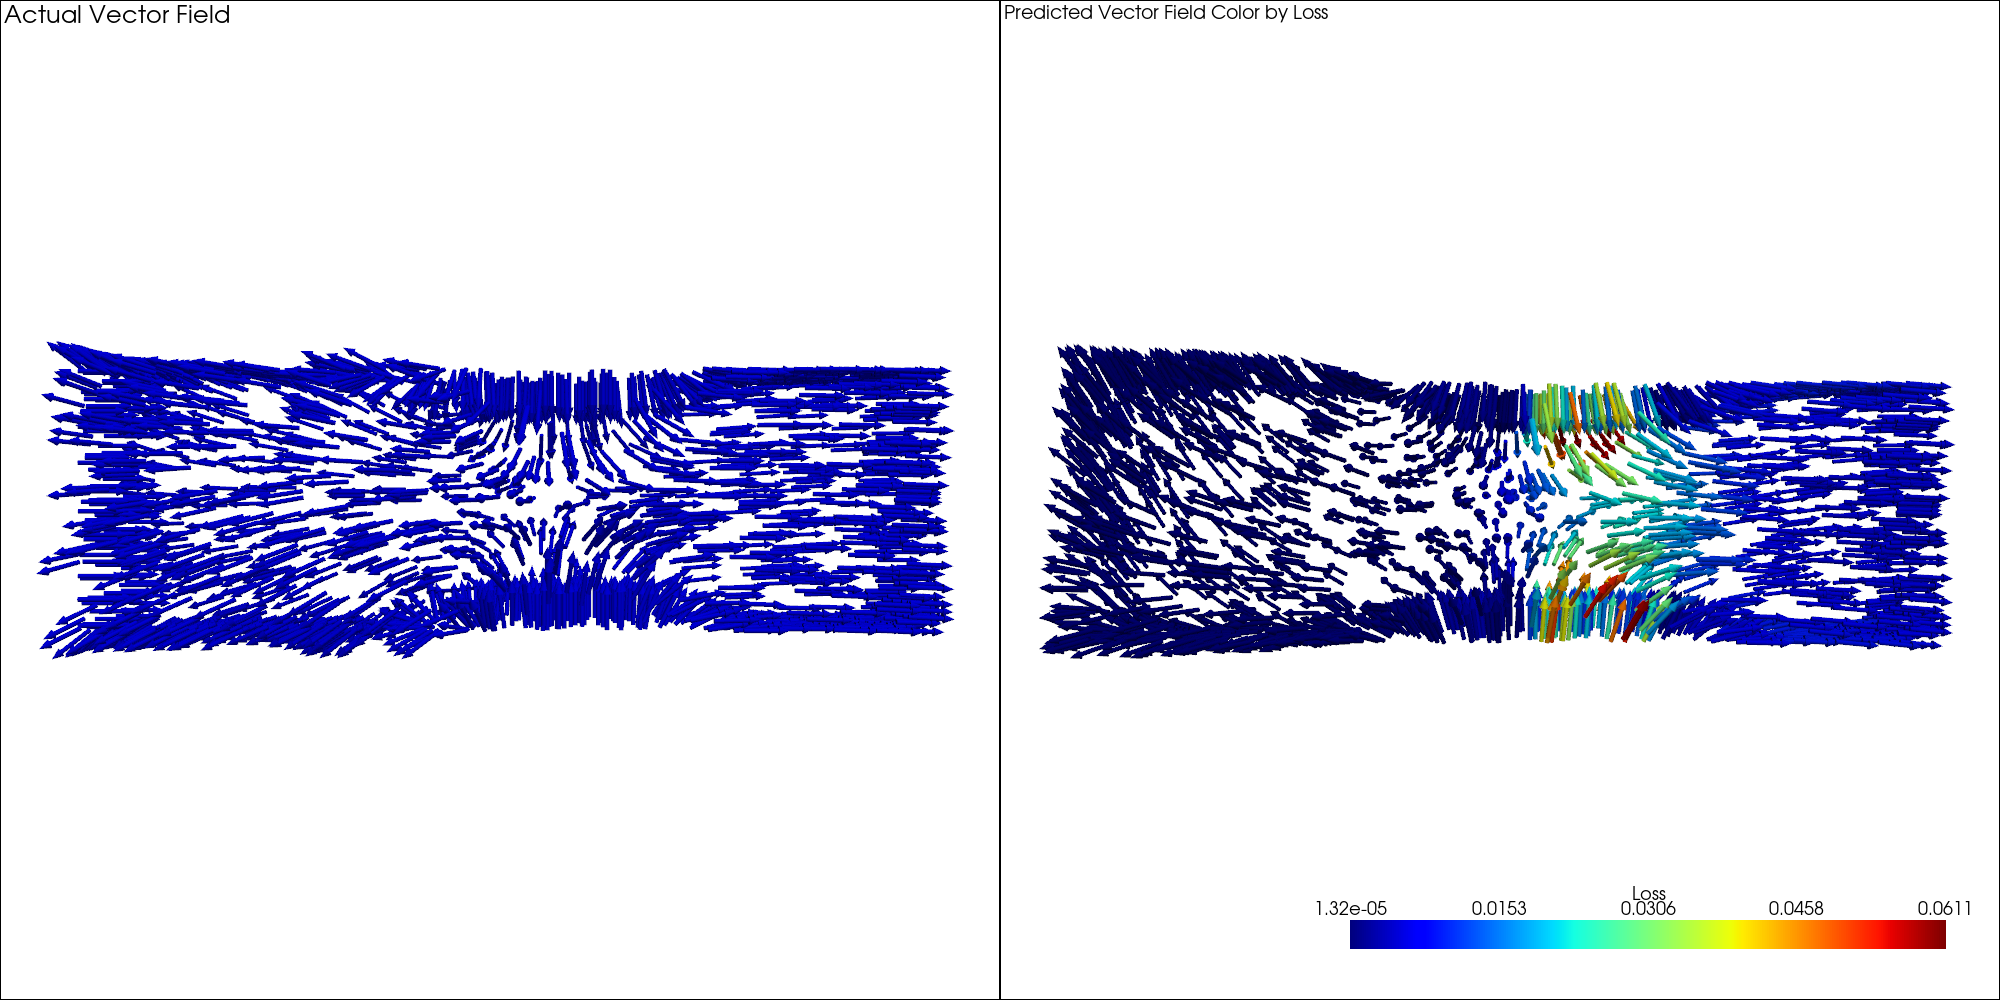

In [9]:
x_t = torch.tensor(start_points, dtype=torch.float32).T.unsqueeze(0).to(trainer.device) # x.shape = 1,3,n_points
x_tp1 = torch.tensor(gt_deformed_points, dtype=torch.float32).T.unsqueeze(0).to(trainer.device) # x.shape = 1,3,n_points

a = torch.tensor(d, dtype=torch.float32).unsqueeze(0).to(trainer.device)
x_t_np = x_t.T.squeeze().cpu().numpy()
x_tp1_np = x_tp1.T.squeeze().cpu().numpy()
delta_hat = forward(x_t,a) / 100
x_tp1_hat = x_t.squeeze(0).T + delta_hat.squeeze(0)
x_tp1_hat = x_tp1_hat.cpu().numpy()
delta_hat = delta_hat.cpu().squeeze().T
delta_gt = (x_tp1 - x_t).squeeze().cpu()    


loss_cont = torch.sum(((delta_hat - delta_gt) ** 2),axis=0).squeeze(0).numpy()

visualize_vector_diff_w_loss_cont(x_t=x_t_np, x_tp1=x_tp1_np, x_hat=x_tp1_hat, 
                                    loss_cont=loss_cont,
                                    fig_path = None)